# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [18]:
import sys

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We start by training the YOLO model with the custom keypoints head on a very small subset of the complete dataset. 

In [4]:
model = detect.CustomHeadedYolo(path="../nets")

# Train the model for some epochs in the dummy dataset.
detect.train_epochs_in(100, None, None, model, testing=True)

epoch 0; train: loss 709.6132202148438; val: loss 793.5338134765625
epoch 1; train: loss 512.6249237060547; val: loss 582.8427124023438
epoch 2; train: loss 302.83050537109375; val: loss 393.1859130859375
epoch 3; train: loss 164.4203872680664; val: loss 269.76177978515625
epoch 4; train: loss 128.5860137939453; val: loss 216.4675750732422
epoch 5; train: loss 105.20069122314453; val: loss 193.82553100585938
epoch 6; train: loss 96.90199279785156; val: loss 169.04478454589844
epoch 7; train: loss 84.2694320678711; val: loss 146.78109741210938
epoch 8; train: loss 77.93191528320312; val: loss 135.99356079101562
epoch 9; train: loss 71.91843795776367; val: loss 129.6371612548828
epoch 10; train: loss 66.94560623168945; val: loss 121.32330322265625
epoch 11; train: loss 62.25419807434082; val: loss 108.76387786865234
epoch 12; train: loss 58.97942924499512; val: loss 96.81631469726562
epoch 13; train: loss 54.47579765319824; val: loss 94.47412872314453
epoch 14; train: loss 50.26235961914

As can be seen above, the basic implementation of the training loop works, decreasing the loss significantly over the epochs. Obviously this is just on a very small subset of the data so we expect significant overfitting to take place here. Below we look at some examples of applying the learned detector on some example images.

In [ ]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/train")

In [28]:
img, ann = data[64]
with torch.inference_mode():
    # Try to run the learned detector on the sample.
    detector = detect.CustomPoseDetector(model)
    mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
    # Try also to use the baseline YOLO model.
    detector2 = detect.PoseDetector(path="../nets", compile=False)
    mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

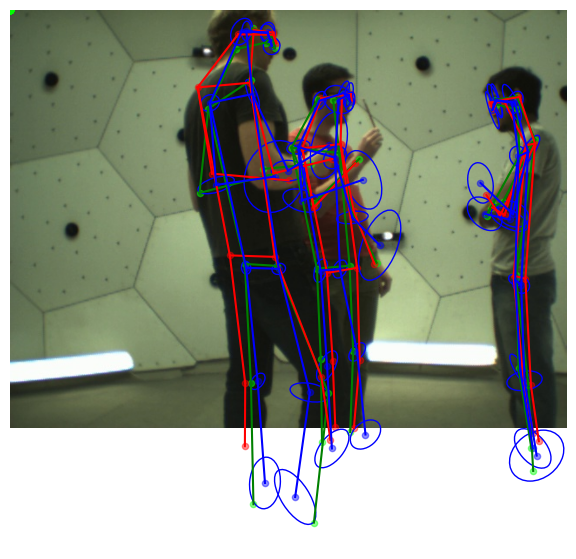

In [52]:
def draw_confidence_ellipse(mean_x, mean_y, cov, ax, n_std=2.0):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(0, vals))
    ellipse = Ellipse(
        xy=(mean_x, mean_y), width=width, height=height,
        angle=theta, facecolor="none", edgecolor="blue")
    return ax.add_patch(ellipse)


# Visualize the results.
fig, ax = plt.subplots(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        ax.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green')
    for k in range(17):
        ax.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        ax.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red')
    for k in range(17):
        ax.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp, cv in zip(mean.cpu().view(-1, 17, 2), util.per_point_cov(cov.cpu(), 2)):
    for i, j in util.SKELETON:
        ax.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue')
    for k in range(17):
        ax.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
        draw_confidence_ellipse(kp[k, 0], kp[k, 1], cv[k].numpy(), ax)
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.autoscale()
plt.axis("off")
plt.show()

As can be seen above, the predictions are not perfect, but they are also not terrible. Note that the red one is the native YOLO prediction, the blue one is the custom heads predictions, and the green skeletons are the ground truth.